In [12]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.components import DistortedLens, PhaseBiprism as Biprism
from temgym_core.run import run_to_end
from temgym_core.source import square_input_wave
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength
from temgym_core.plotting import plot_model, PlotParams

In [13]:
window_width = 1e-6  # metres
Nx = Ny = 256
pixel_size = window_width / Nx
voltage = 200e3  # volts
wavelength = energy2wavelength(voltage)
k = 2 * np.pi / wavelength
input_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)

input_extent = input_grid.extent

In [14]:
rays_in = square_input_wave(voltage=200e3, 
                            aperture_length=window_width*0.9, 
                            waist=2e-9)

In [4]:
run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)), static_argnums=(1,)
)
rays_out = run_to_end_vmapped(rays_in, ())
field = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid).block_until_ready()

Text(0, 0.5, 'y (µm)')

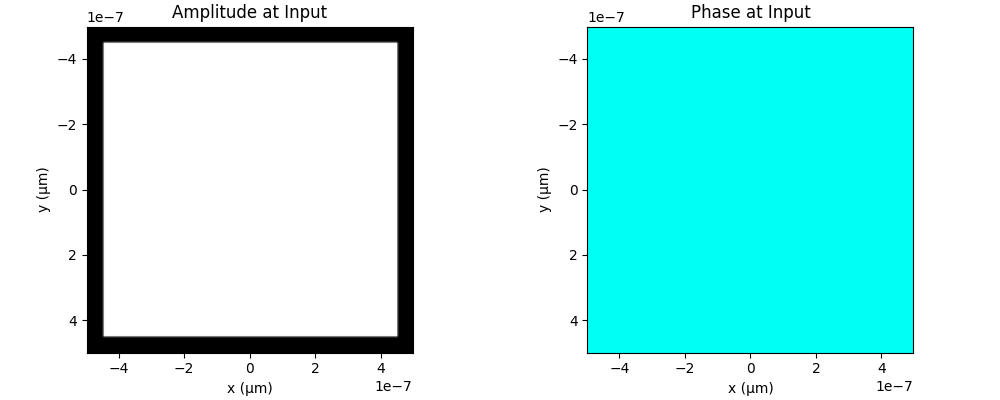

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im0 = axs[0].imshow(
    np.abs(field),
    extent=input_extent,
    cmap='gray',
)
axs[0].set_title('Amplitude at Input')
axs[0].set_xlabel('x (\u00b5m)')
axs[0].set_ylabel('y (\u00b5m)')

im1 = axs[1].imshow(
    np.angle(field),
    extent=input_extent,
    cmap='hsv',
    vmin=-np.pi,
    vmax=np.pi,
)
axs[1].set_title('Phase at Input')
axs[1].set_xlabel('x (\u00b5m)')
axs[1].set_ylabel('y (\u00b5m)')

In [15]:
M1, f1 = -1000, 1e-3
defocus = 0.0
z1, z2 = calculate_z1_and_z2_from_M_and_f(M=M1, f=f1)
z1, z2 = map(abs, (z1, z2))

aberrated_lens = DistortedLens(z=z1, object_plane_dist=z1, focal_length=f1, IsoDist=1.5e14)
biprism = Biprism(z=(z1 + z2) / 2, strength=0.0005, width=1e-11)
detector = Detector(
    z=z1 + z2 + defocus,
    pixel_size=(pixel_size * abs(M1), pixel_size * abs(M1)),
    shape=(Ny, Nx),
)
extent = detector.extent
extent_um = tuple(float(val) * 1e6 for val in extent)

In [7]:
rays_out_no_biprism = run_to_end_vmapped(rays_in, (aberrated_lens, detector))
field_no_biprism = evaluate_gaussians_gpu_kernel_wrapper(rays_out_no_biprism, detector).block_until_ready()
field_no_biprism_intensity = np.abs(field_no_biprism) ** 2

In [8]:
rays_out_with_biprism = run_to_end_vmapped(rays_in, (aberrated_lens, biprism, detector))
field_with_biprism = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_biprism, detector).block_until_ready()
field_with_biprism_intensity = np.abs(field_with_biprism) ** 2

/tmp/ipykernel_3011535/1308005115.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


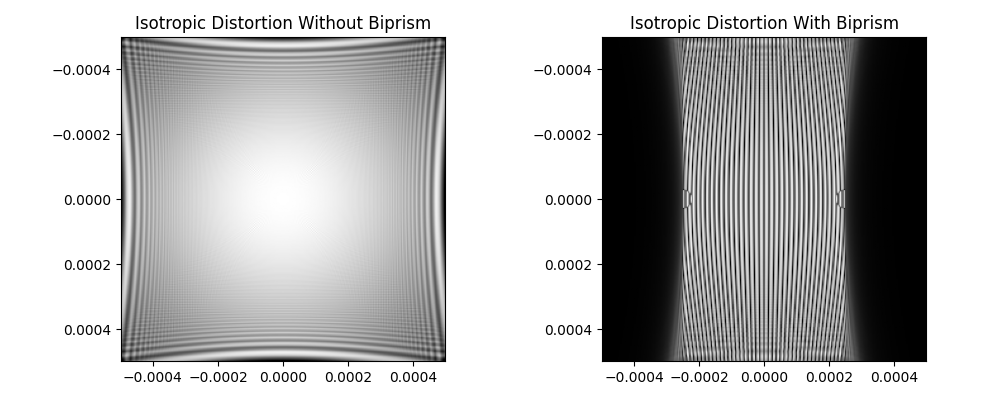

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axs[0].imshow(np.abs(field_no_biprism), extent=extent, cmap='gray')
axs[0].set_title('Isotropic Distortion Without Biprism')
axs[1].imshow(np.abs(field_with_biprism), extent=extent, cmap='gray')
# axs[1].plot(rays_out_with_biprism.x, rays_out_with_biprism.y, 'w.', markersize=0.5, alpha=0.1)
axs[1].set_title('Isotropic Distortion With Biprism')
plt.tight_layout()

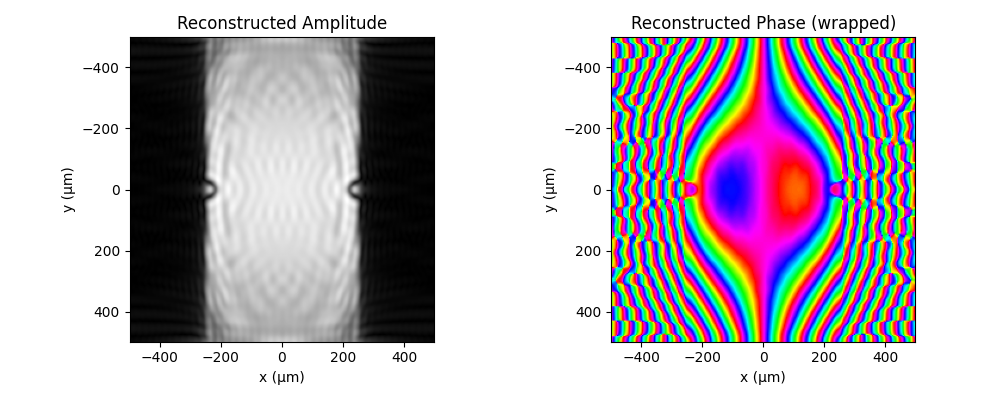

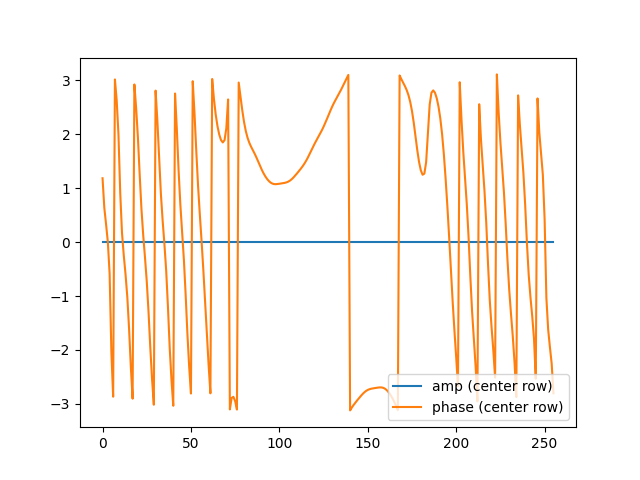

In [10]:
def reconstruct_complex(hologram, exclude_radius=10, sigma_pixels=25, sideband_center=None):
    """
    Simple off-axis hologram reconstruction:
    - FFT the hologram
    - find a sideband (optionally provided)
    - isolate it with a circular mask of radius=sigma_pixels
    - shift that sideband to the DC location and inverse FFT to obtain complex field
    Returns dict with 'complex', 'amplitude', 'phase_wrapped'.
    """
    H = np.asarray(hologram)
    Ny, Nx = H.shape
    # centered FFT
    Hf = np.fft.fftshift(np.fft.fft2(H))

    center = np.array([Ny // 2, Nx // 2])

    # find sideband peak if not supplied
    if sideband_center is None:
        mag = np.abs(Hf)
        yy, xx = np.indices(H.shape)
        dist = np.sqrt((yy - center[0])**2 + (xx - center[1])**2)
        masked = mag.copy()
        masked[dist <= exclude_radius] = 0
        peak_idx = np.unravel_index(np.argmax(masked), H.shape)
    else:
        # allow passing either (y,x) or (x,y)
        sc = tuple(map(int, sideband_center))
        if len(sc) != 2:
            raise ValueError("sideband_center must be (y,x) or (x,y)")
        peak_idx = (sc[0], sc[1])

    # build circular mask around the detected peak
    win = int(max(2, sigma_pixels))
    yy, xx = np.indices(H.shape)
    mask = (xx - peak_idx[1])**2 + (yy - peak_idx[0])**2 <= win**2

    # isolate and shift the sideband to center
    Hf_side = Hf * mask
    shift = (center[0] - peak_idx[0], center[1] - peak_idx[1])
    Hf_centered = np.roll(Hf_side, shift=shift, axis=(0, 1))

    # inverse transform (note use ifft2(of ifftshift(...)) because Hf was fftshifted originally)
    field = np.fft.ifft2(np.fft.ifftshift(Hf_centered))

    return {
        'complex': field,
        'amplitude': np.abs(field),
        'phase_wrapped': np.angle(field),
        'sideband_center': peak_idx,
        'mask_radius': win,
    }


# Run reconstruction on the recorded intensity
ref = reconstruct_complex(field_with_biprism_intensity, exclude_radius=10, sigma_pixels=25, sideband_center=None)

phase = ref['phase_wrapped']
amplitude = ref['amplitude']

# show results (extent_um already in micrometres)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(amplitude, extent=extent_um, cmap='gray')
plt.title('Reconstructed Amplitude')
plt.xlabel('x (µm)'); plt.ylabel('y (µm)')

plt.subplot(1,2,2)
plt.imshow(phase, extent=extent_um, cmap='hsv', vmin=-np.pi, vmax=np.pi)
plt.title('Reconstructed Phase (wrapped)')
plt.xlabel('x (µm)'); plt.ylabel('y (µm)')
plt.tight_layout()

# quick central cross-sections
plt.figure()
plt.plot(amplitude[Nx//2, :], label='amp (center row)')
plt.plot(phase[Nx//2, :], label='phase (center row)')
plt.legend()

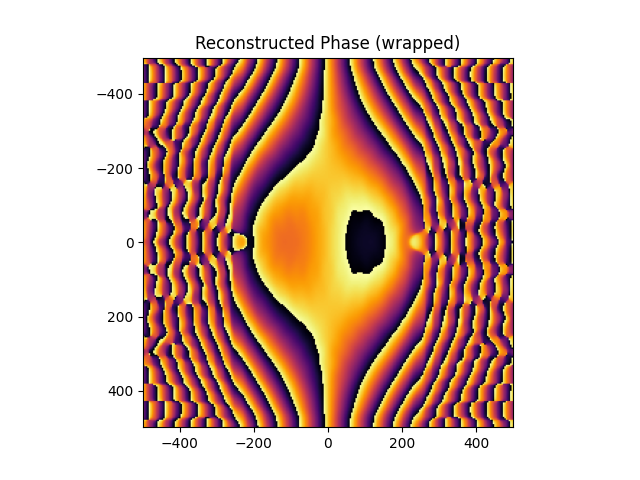

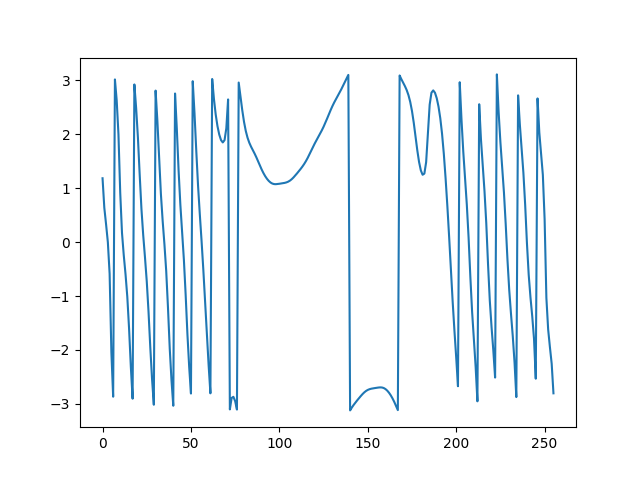

In [11]:
plt.figure()
plt.imshow(phase, extent=extent_um, cmap='inferno')
plt.title('Reconstructed Phase (wrapped)')

plt.figure()
plt.plot(phase[Nx//2, :])

Text(0.5, 1.0, 'Off-axis holography: DistortedLens (IsoDist=1.5e+14) + biprism')

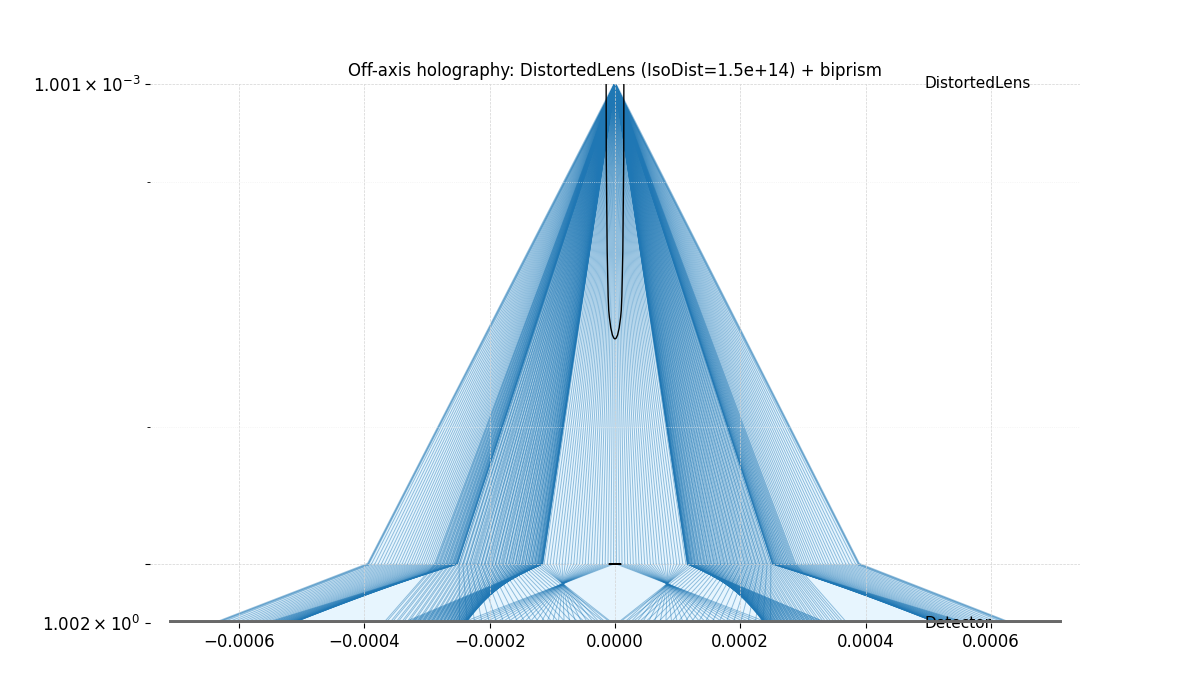

In [26]:
# Subsample rays for a clean ray diagram.
plot_stride = max(len(rays_in.x) // 400, 1)
rays_for_plot = rays_in[0::plot_stride].derive(voltage=voltage)

# The lens is at z1 ≈ 1 mm while the detector is at ~1 m — a 1000:1 ratio.
# On a linear z-scale the lens region collapses to <0.1% of the plot
# and rays look like vertical lines.  Use symlog to expand the lens region
# while compressing the long drift between biprism and detector.
#
# CRITICAL: auto_lens_height must be True, otherwise the lens arc
# (specified in metres) is invisible on a metre-scale z-axis.
# Similarly biprism_radius must be large enough for the x-scale (~500 µm).
fig, ax = plot_model(
    components=[aberrated_lens, biprism, detector],
    rays=rays_for_plot,
    ray_coordinate="r",
    r_side_by_sign=True,
    include_input_rays=False,
    yscale="symlog",
    y_linthresh=2e-2,
    plot_params=PlotParams(
        figsize=(12, 7),
        ray_lw=0.7,
        ray_alpha=0.45,
        auto_lens_height=True,
        lens_height_frac=0.04,
        biprism_radius=1e-5,
    ),
)
ax.set_title("Off-axis holography: DistortedLens (IsoDist={:.1e}) + biprism".format(
    aberrated_lens.IsoDist))